In [1]:
from pathlib import Path

repo = Path("/content/MMA3001_Project")

if not repo.exists():
    !git clone https://github.com/daniellawjmcc/MMA3001_Project.git

%cd /content/MMA3001_Project

/content/MMA3001_Project


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path

dataset_root = Path(
    "/content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v4_clean"
)

yaml_path = dataset_root / "data.yaml"

print("Dataset exists:", dataset_root.exists())
print("YAML exists:", yaml_path.exists())

Dataset exists: True
YAML exists: True


# MMA3001 Dataset 3 — Baseline Object Detection Model

This notebook develops the initial object-detection baseline for the pork rasher packaging-defect dataset.

The baseline is trained using the cleaned dataset produced during the data-audit stage.

The objectives are to:

- establish a reproducible baseline model;
- measure validation performance;
- inspect class-specific detection performance;
- identify failure cases and limitations; and
- provide a reference for later model improvements or alternative approaches.

## 1. Training Environment

The baseline model is developed using Ultralytics YOLOv8.

A small YOLOv8n model is used as the initial baseline because it provides a lightweight reference for evaluating object-detection performance before model settings or architecture are modified.

The cleaned dataset produced during the data-audit stage is used for all model development.

In [4]:
!pip install -q ultralytics

In [5]:
import torch
import ultralytics

print("PyTorch version:", torch.__version__)
print("Ultralytics version:", ultralytics.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not detected")

PyTorch version: 2.11.0+cu128
Ultralytics version: 8.4.165
CUDA available: True
GPU: Tesla T4


In [6]:
!nvidia-smi

Tue Sep 29 04:26:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
from pathlib import Path

dataset_root = Path(
    "/content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v4_clean"
)

yaml_path = dataset_root / "data.yaml"

print("Dataset root:", dataset_root)
print("Dataset exists:", dataset_root.exists())
print("data.yaml exists:", yaml_path.exists())

Dataset root: /content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v4_clean
Dataset exists: True
data.yaml exists: True


## 2. Baseline Model

YOLOv8n is selected as the initial object-detection baseline.

The `n` model is the smallest YOLOv8 variant and provides a lightweight starting point for assessing whether the dataset can support reliable defect detection before introducing additional model complexity or optimisation.

Pretrained weights are used as the initial model parameters. The baseline is trained using fixed settings so that later experiments can be compared against the same reference model.

Baseline settings:

- Model: YOLOv8n
- Image size: 640 × 640
- Epochs: 30
- Batch size: 16
- Random seed: 42
- GPU training
- Default Ultralytics augmentation and optimisation settings unless otherwise specified

In [8]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8n model loaded successfully.")

YOLOv8n model loaded successfully.


In [9]:
from pathlib import Path

runs_dir = Path(
    "/content/drive/MyDrive/MMA3001_Project/model_runs"
)

runs_dir.mkdir(parents=True, exist_ok=True)

print("Training results will be saved to:")
print(runs_dir)

Training results will be saved to:
/content/drive/MyDrive/MMA3001_Project/model_runs


In [ ]:
results = model.train(
    data=str(yaml_path),
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    seed=42,
    workers=2,
    project=str(runs_dir),
    name="yolov8n_v1_baseline",
    plots=True
)

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v4_clean/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_v1_

## 3. Baseline Validation

The trained baseline model is evaluated using the validation set.

Object-detection performance is assessed using:

- **Precision** — proportion of predicted detections that are correct;
- **Recall** — proportion of labelled defects that are successfully detected;
- **mAP@50** — mean average precision using an IoU threshold of 0.50;
- **mAP@50:95** — mean average precision averaged across IoU thresholds from 0.50 to 0.95.

The validation set is used for model development and comparison. The independent test set is reserved for final evaluation after model selection.

In [11]:
from ultralytics import YOLO
from pathlib import Path

run_dir = Path(
    "/content/drive/MyDrive/MMA3001_Project/model_runs/yolov8n_v1_baseline"
)

best_model = YOLO(run_dir / "weights" / "best.pt")

print("Best model loaded successfully.")

Best model loaded successfully.


In [12]:
val_metrics = best_model.val(
    data=str(yaml_path),
    split="val",
    device=0
)

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.4±0.1 ms, read: 12.1±25.8 MB/s, size: 66.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v4_clean/valid/labels... 123 images, 14 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 2.7it/s 45.3s
val: New cache created: /content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v4_clean/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.9it/s 2.7s
                   all        123        124       0.75      0.525      0.532      0.245
            loose-meat          3          3          1      0.546      0.665      0.204
       pa

In [13]:
print(f"Precision:   {val_metrics.box.mp:.4f}")
print(f"Recall:      {val_metrics.box.mr:.4f}")
print(f"mAP@50:      {val_metrics.box.map50:.4f}")
print(f"mAP@50:95:   {val_metrics.box.map:.4f}")

Precision:   0.7496
Recall:      0.5252
mAP@50:      0.5321
mAP@50:95:   0.2445


In [14]:
print("Per-class performance:\n")

for class_id, class_name in best_model.names.items():
    print(
        f"{class_name:20s} "
        f"mAP@50:95 = {val_metrics.box.maps[class_id]:.4f}"
    )

Per-class performance:

loose-meat           mAP@50:95 = 0.2036
packaging-error      mAP@50:95 = 0.1237
twisted-meat         mAP@50:95 = 0.2552
unsealed             mAP@50:95 = 0.6402
wrinkle              mAP@50:95 = 0.0000


### Baseline Validation Results

The YOLOv8n baseline achieved:

- Precision: 0.7496
- Recall: 0.5252
- mAP@50: 0.5321
- mAP@50:95: 0.2445

The model shows reasonably high precision, indicating that many predicted defects are correct. However, recall is substantially lower, showing that a considerable proportion of labelled defects are missed.

The difference between mAP@50 and mAP@50:95 also indicates that localisation accuracy decreases under stricter IoU requirements.

These results establish the baseline for subsequent model improvement and comparison. Particular attention should be given to recall, class-specific performance and bounding-box localisation.

In [ ]:
from PIL import Image
from IPython.display import display

display(Image.open(run_dir / "results.png"))
display(Image.open(run_dir / "confusion_matrix.png"))

## 4. Experiment 2 — Increased Training Duration

The baseline training curves showed that training losses were still decreasing and validation mAP was still generally improving near epoch 30.

This suggested that the baseline may not have fully converged.

To investigate the effect of training duration, a second YOLOv8n model is trained for 60 epochs while keeping the remaining model settings unchanged.

This provides a controlled comparison in which training duration is the primary modified variable.

In [19]:
from ultralytics import YOLO

model_v2 = YOLO("yolov8n.pt")

results_v2 = model_v2.train(
    data=str(yaml_path),
    epochs=60,
    imgsz=640,
    batch=16,
    device=0,
    seed=42,
    workers=2,
    project=str(runs_dir),
    name="yolov8n_v2_60epochs",
    plots=True
)

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v4_clean/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_v2_

In [23]:
from ultralytics import YOLO
from pathlib import Path

best_v2_path = Path(
    "/content/drive/MyDrive/MMA3001_Project/model_runs/"
    "yolov8n_v2_60epochs-2/weights/best.pt"
)

best_model_v2 = YOLO(best_v2_path)

print("V2 model loaded successfully.")

val_metrics_v2 = best_model_v2.val(
    data=str(yaml_path),
    split="val",
    imgsz=640,
    device=0,
    workers=0
)

V2 model loaded successfully.
Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 3.1±4.7 ms, read: 40.5±23.0 MB/s, size: 66.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v4_clean/valid/labels.cache... 123 images, 14 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 46.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.9it/s 2.7s
                   all        123        124      0.842      0.451       0.46       0.29
            loose-meat          3          3      0.892      0.333      0.335      0.268
       packaging-error         23         34      0.448      0.406      0.386      

In [26]:
print(f"Precision:   {val_metrics_v2.box.mp:.4f}")
print(f"Recall:      {val_metrics_v2.box.mr:.4f}")
print(f"mAP@50:      {val_metrics_v2.box.map50:.4f}")
print(f"mAP@50:95:   {val_metrics_v2.box.map:.4f}")

print("\nPer-class mAP@50:95:\n")

for class_id, class_name in best_model_v2.names.items():
    print(
        f"{class_name:20s} "
        f"{val_metrics_v2.box.maps[class_id]:.4f}"
    )

Precision:   0.8419
Recall:      0.4507
mAP@50:      0.4599
mAP@50:95:   0.2903

Per-class mAP@50:95:

loose-meat           0.2680
packaging-error      0.1203
twisted-meat         0.4493
unsealed             0.6140
wrinkle              0.0000


In [25]:
print("\nPer-class mAP@50:95:\n")

for class_id, class_name in best_model_v2.names.items():
    print(
        f"{class_name:20s} "
        f"{val_metrics_v2.box.maps[class_id]:.4f}"
    )


Per-class mAP@50:95:

loose-meat           0.2680
packaging-error      0.1203
twisted-meat         0.4493
unsealed             0.6140
wrinkle              0.0000


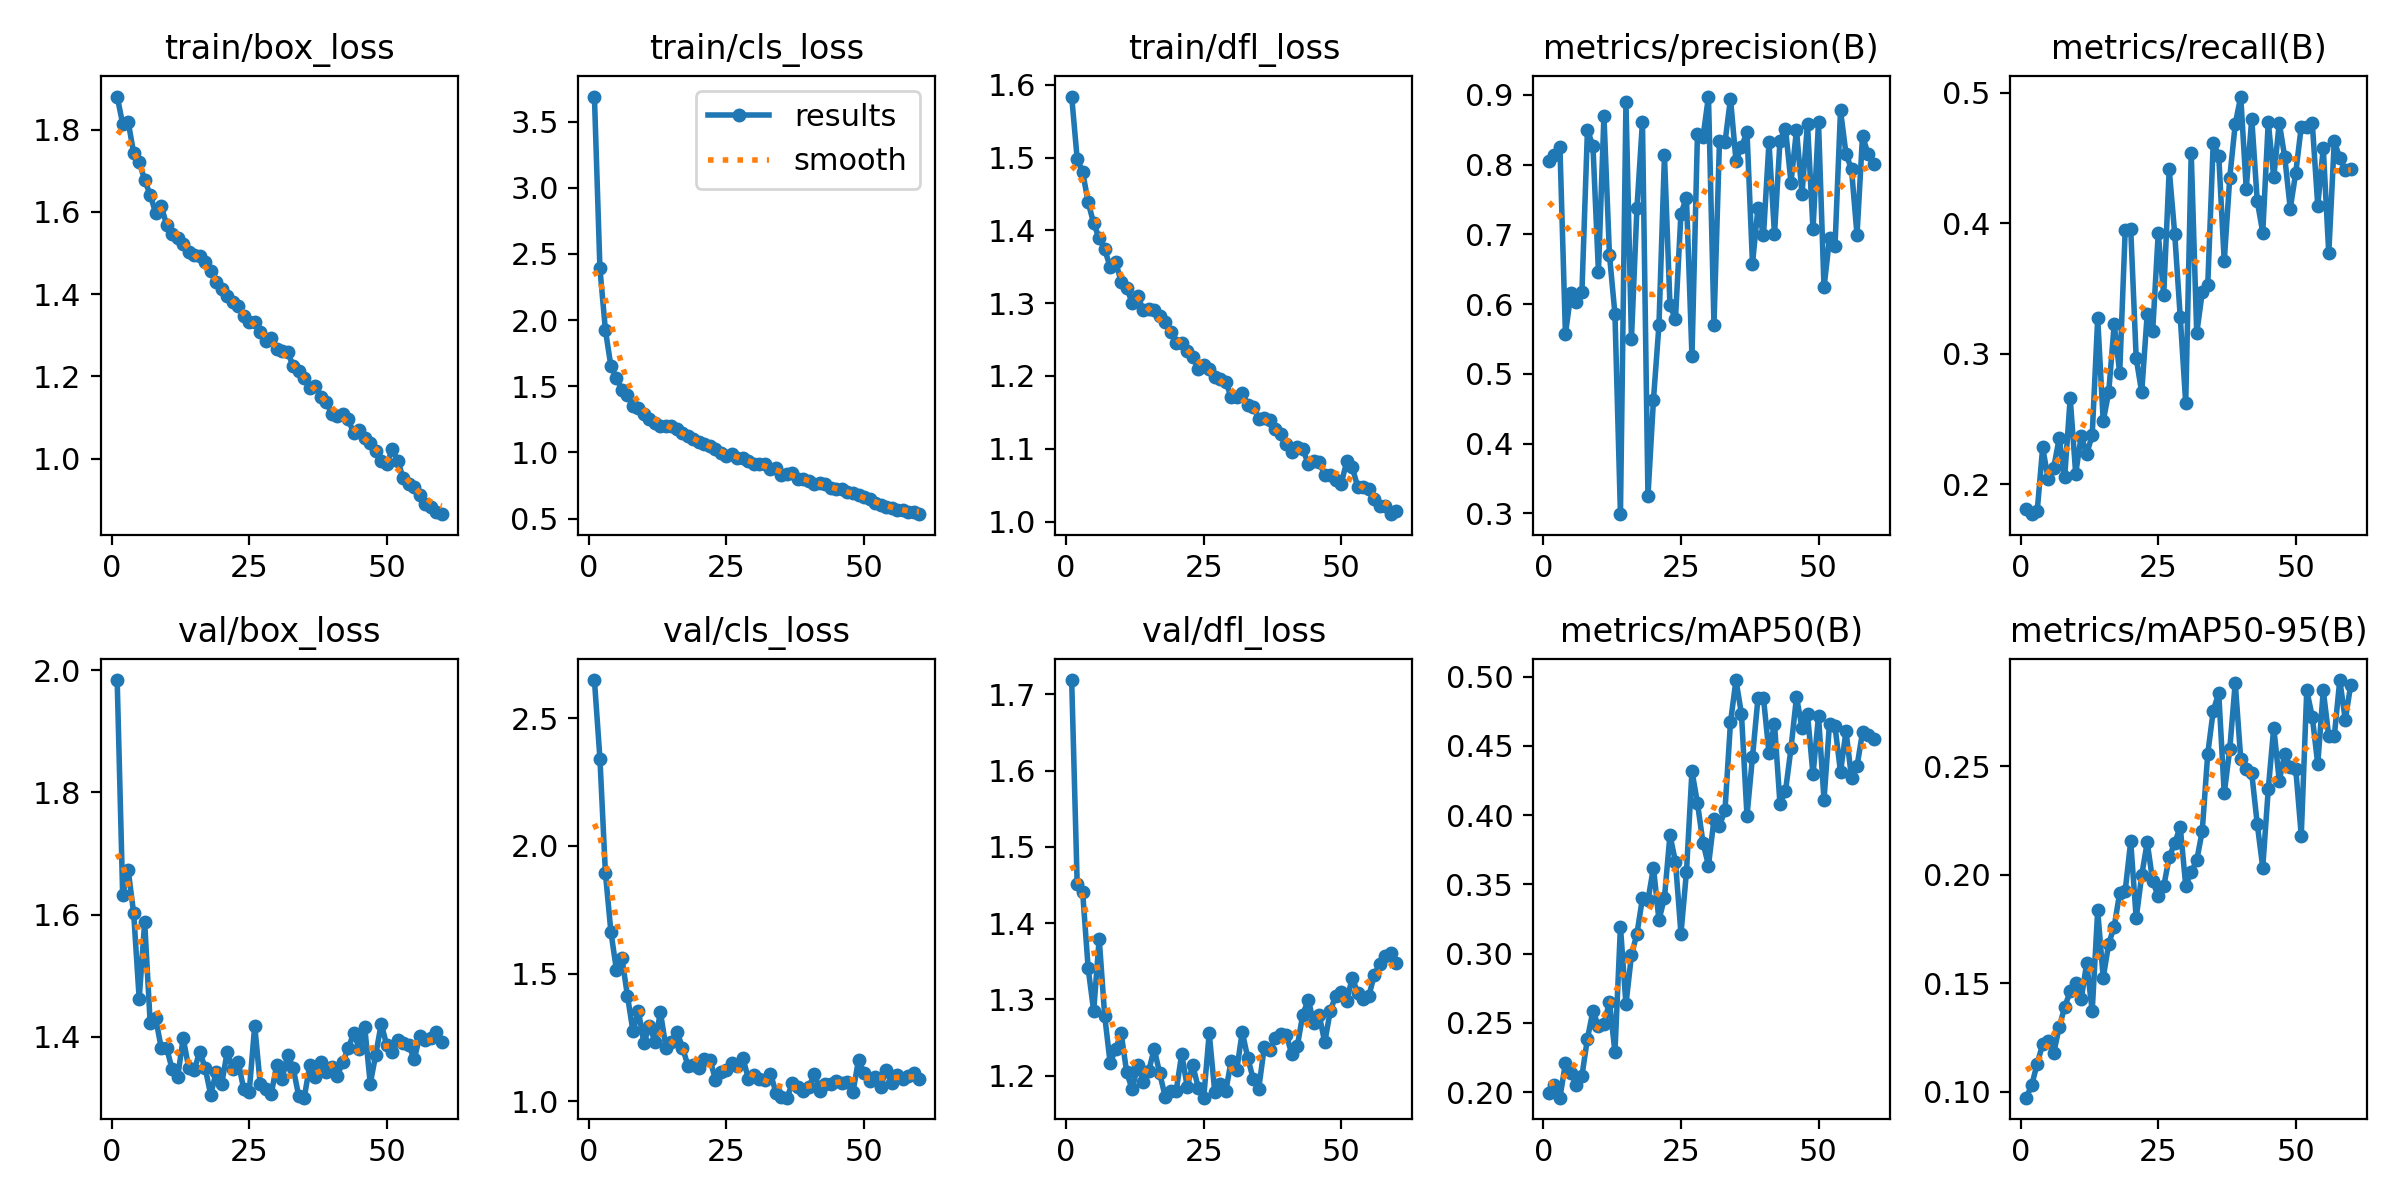

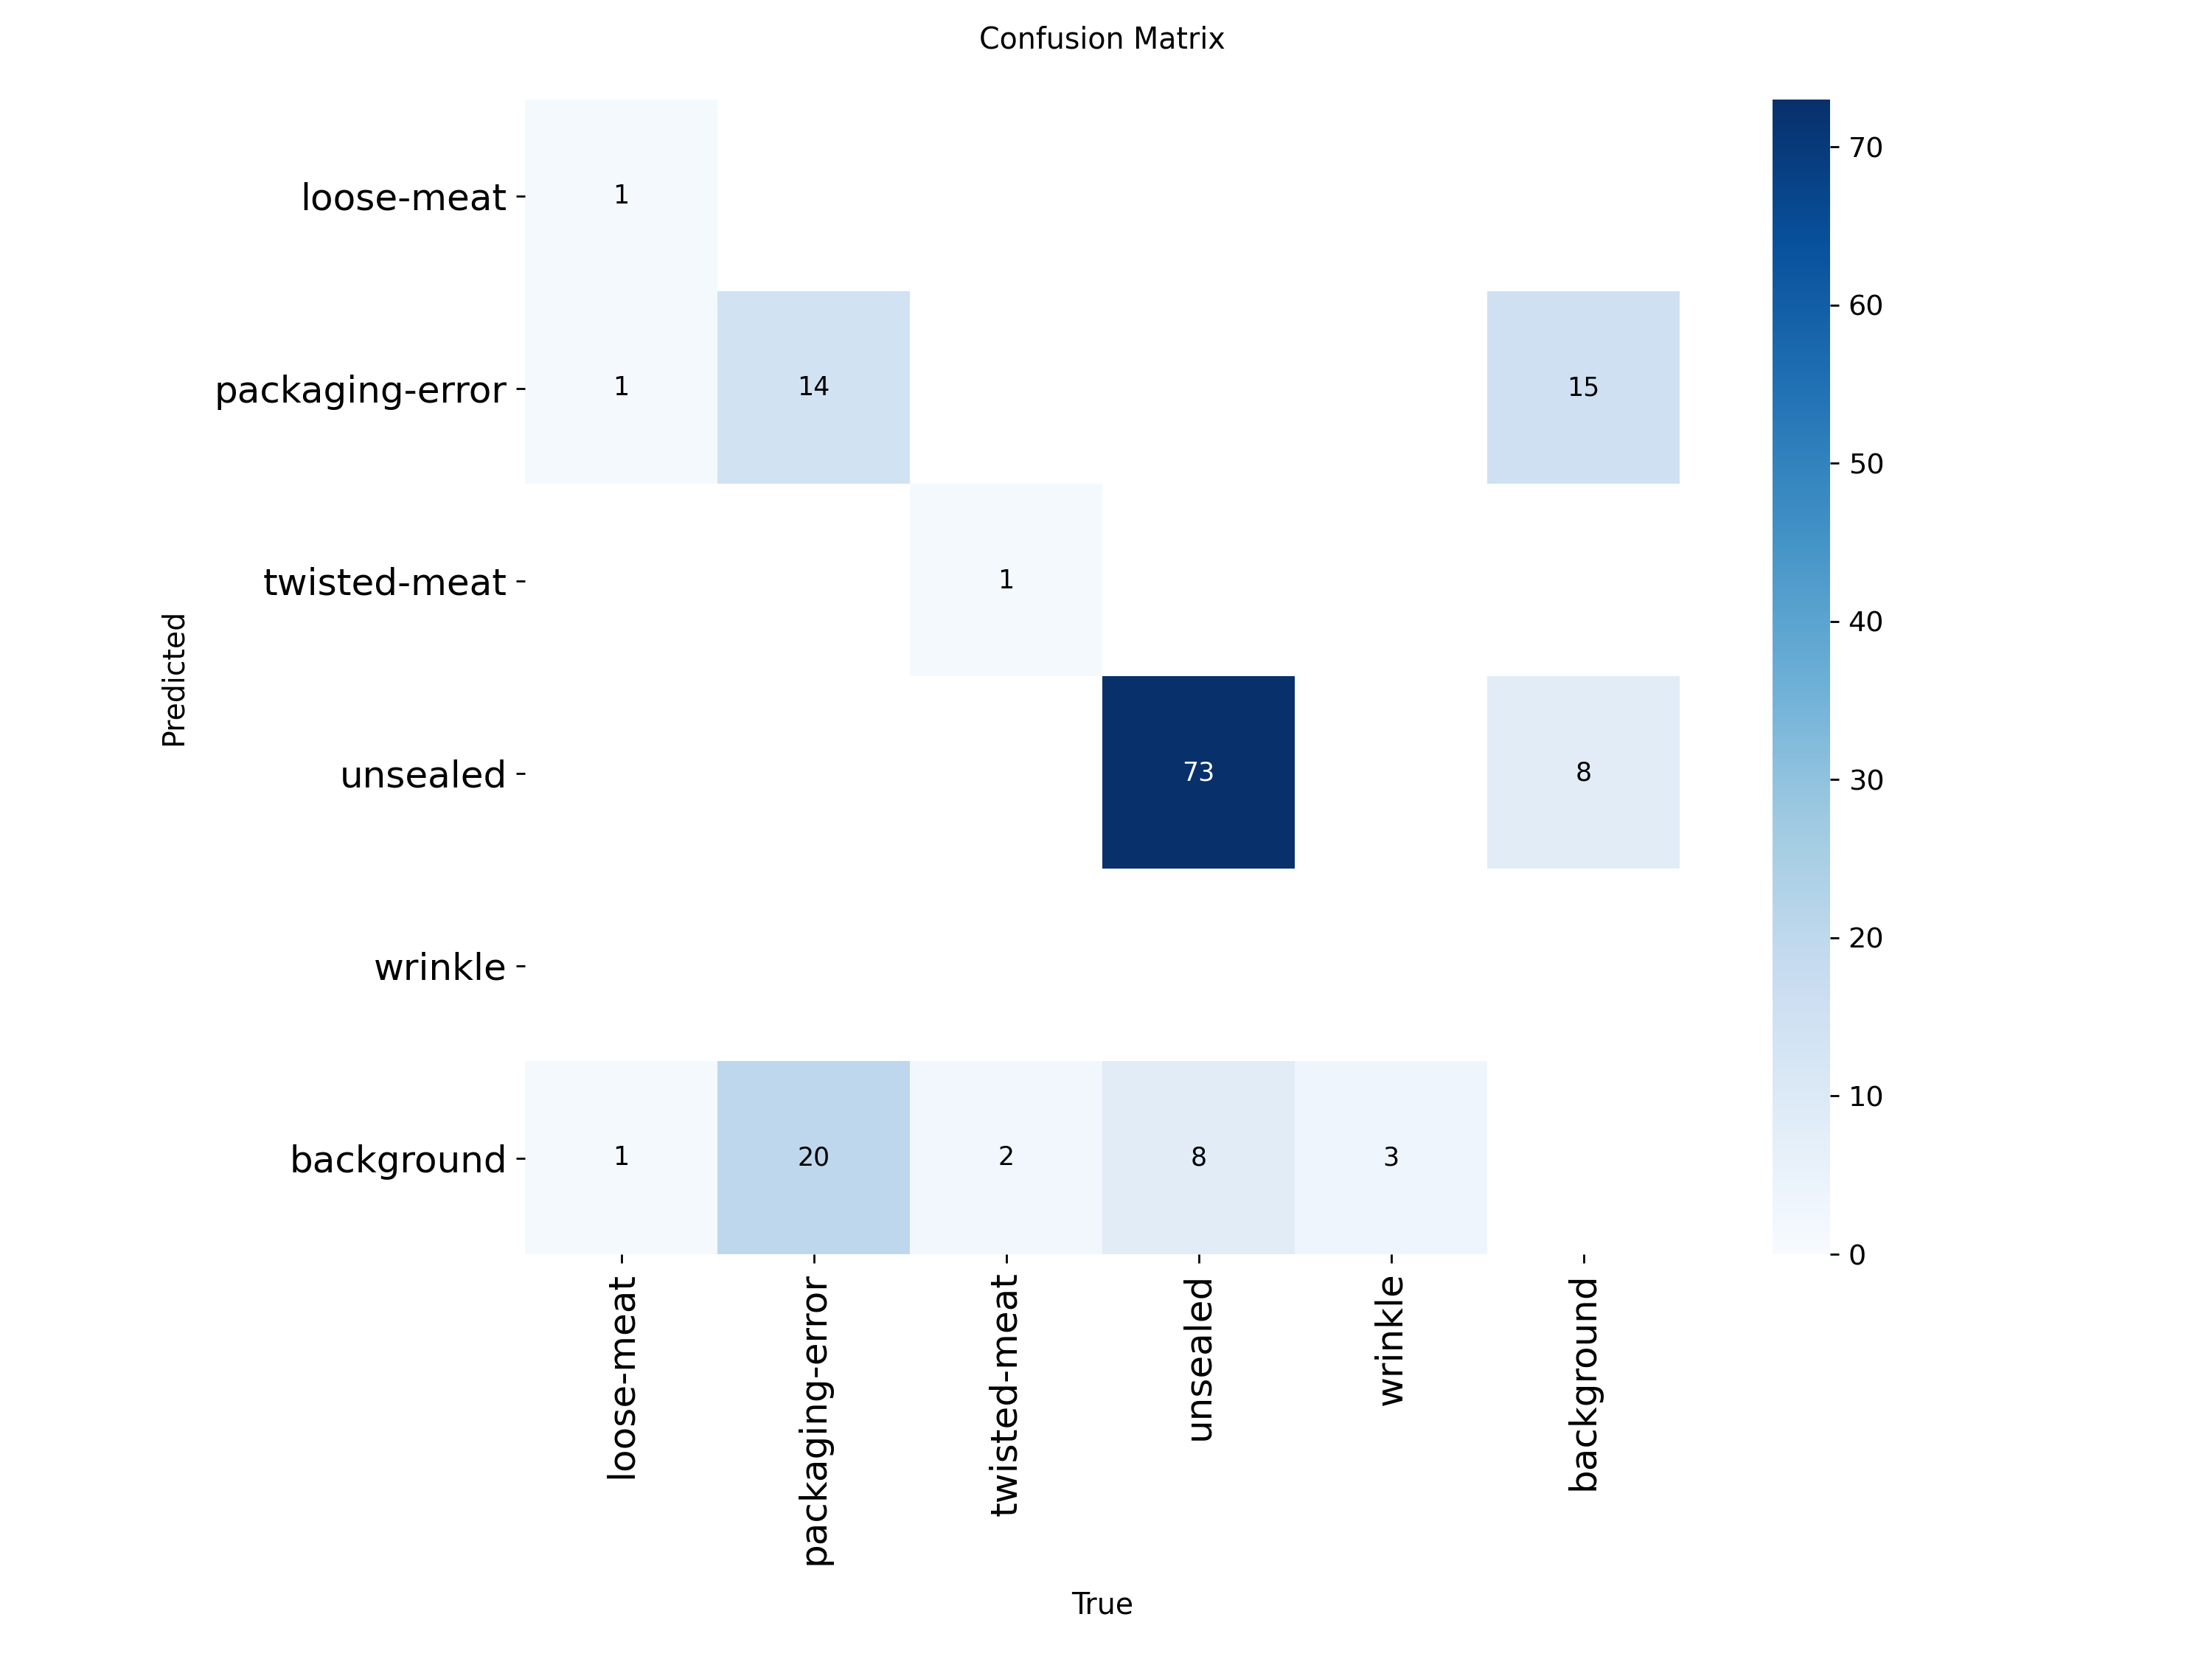

In [28]:
from pathlib import Path
from PIL import Image
from IPython.display import display

run_dir_v2 = Path(
    "/content/drive/MyDrive/MMA3001_Project/model_runs/"
    "yolov8n_v2_60epochs-2"
)

display(Image.open(run_dir_v2 / "results.png"))
display(Image.open(run_dir_v2 / "confusion_matrix.png"))

In [29]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "YOLOv8n - 30 epochs",
        "YOLOv8n - 60 epochs"
    ],
    "Precision": [
        0.7496,
        0.8419
    ],
    "Recall": [
        0.5252,
        0.4507
    ],
    "mAP@50": [
        0.5321,
        0.4599
    ],
    "mAP@50:95": [
        0.2445,
        0.2903
    ]
})

comparison

,Model,Precision,Recall,mAP@50,mAP@50:95
0,YOLOv8n - 30 epochs,0.7496,0.5252,0.5321,0.2445
1,YOLOv8n - 60 epochs,0.8419,0.4507,0.4599,0.2903


In [30]:
class_comparison = pd.DataFrame({
    "Class": [
        "loose-meat",
        "packaging-error",
        "twisted-meat",
        "unsealed",
        "wrinkle"
    ],
    "V1_30_epochs": [
        0.2036,
        0.1237,
        0.2552,
        0.6402,
        0.0000
    ],
    "V2_60_epochs": [
        0.2680,
        0.1203,
        0.4493,
        0.6140,
        0.0000
    ]
})

class_comparison

,Class,V1_30_epochs,V2_60_epochs
0,loose-meat,0.2036,0.2680
1,packaging-error,0.1237,0.1203
2,twisted-meat,0.2552,0.4493
3,unsealed,0.6402,0.6140
4,wrinkle,0.0000,0.0000


### YOLOv8n Training-Duration Comparison

Increasing the training duration from 30 to 60 epochs produced mixed results.

The 60-epoch model achieved higher precision and higher mAP@50:95, but lower recall and lower mAP@50. Class-specific performance also varied. Loose-meat and twisted-meat improved, while packaging-error and unsealed showed little improvement, and wrinkle remained undetected.

The experiment therefore shows that increasing training duration alone does not consistently improve all aspects of defect detection.

The YOLOv8n results are retained as the baseline for comparison with an alternative object-detection architecture.